In [ ]:
import pandas as pd
import numpy as np

# Soo akhri 3-da file
student = pd.read_csv('Dataset/studentInfo.csv')
course = pd.read_csv('Dataset/courses.csv')
student_registration = pd.read_csv('Dataset/studentRegistration.csv')

# Eeg shape iyo columns si aan u hubino in si sax ah loo soo akhriyay
print("student shape:", student.shape)
print("student columns:", student.columns.tolist())
print()
print("course shape:", course.shape)
print("course columns:", course.columns.tolist())
print()
print("student_registration shape:", student_registration.shape)
print("student_registration columns:", student_registration.columns.tolist())

student shape: (32593, 12)
student columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

course shape: (22, 3)
course columns: ['code_module', 'code_presentation', 'module_presentation_length']

student_registration shape: (32593, 5)
student_registration columns: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']


In [2]:
# Select kaliya columns-ka aan u baahanahay student.csv (ka tag sensitive: gender, region, imd_band, disability)
student_static = student[[
    'id_student', 'code_module', 'code_presentation',
    'studied_credits', 'num_of_prev_attempts',
    'highest_education', 'age_band', 'final_result'
]].copy()

# Merge student_static + course via code_module + code_presentation
base_df = student_static.merge(
    course, on=['code_module', 'code_presentation'], how='left'
)

# Merge base_df + student_registration via id_student + code_module + code_presentation
base_df = base_df.merge(
    student_registration, on=['id_student', 'code_module', 'code_presentation'], how='left'
)

# Abuur enrollment_id
base_df['enrollment_id'] = (
    base_df['id_student'].astype(str) + '_' +
    base_df['code_module'] + '_' +
    base_df['code_presentation']
)

# Hubi inaan jirin duplicate enrollment_id
duplicates = base_df['enrollment_id'].duplicated().sum()
print("Tirada duplicate enrollment_id:", duplicates)

# Abuur risk_label: Withdrawn/Fail = 1, Pass/Distinction = 0
base_df['risk_label'] = base_df['final_result'].map({
    'Withdrawn': 1,
    'Fail': 1,
    'Pass': 0,
    'Distinction': 0
})

# Hubi in aan jirin NaN risk_label (final_result aan la map gareyn)
print("NaN risk_label count:", base_df['risk_label'].isna().sum())

print("\nbase_df shape:", base_df.shape)
print("base_df columns:", base_df.columns.tolist())
print("\nbase_df.head():")
print(base_df.head())

print("\nNaN counts per column:")
print(base_df.isna().sum())

Tirada duplicate enrollment_id: 0
NaN risk_label count: 0

base_df shape: (32593, 13)
base_df columns: ['id_student', 'code_module', 'code_presentation', 'studied_credits', 'num_of_prev_attempts', 'highest_education', 'age_band', 'final_result', 'module_presentation_length', 'date_registration', 'date_unregistration', 'enrollment_id', 'risk_label']

base_df.head():
   id_student code_module code_presentation  studied_credits  \
0       11391         AAA             2013J              240   
1       28400         AAA             2013J               60   
2       30268         AAA             2013J               60   
3       31604         AAA             2013J               60   
4       32885         AAA             2013J               60   

   num_of_prev_attempts      highest_education age_band final_result  \
0                     0       HE Qualification     55<=         Pass   
1                     0       HE Qualification    35-55         Pass   
2                     0  A Leve

In [3]:
# 45 ardayda aan lahayn date_registration - eeg sida ay u kala qaybsamaan
print("Rows with NaN date_registration:")
print(base_df[base_df['date_registration'].isna()][['final_result', 'risk_label']].value_counts())

# Fill NaN date_registration with 0 (assume registered at start, day 0)
base_df['date_registration'] = base_df['date_registration'].fillna(0)

# Calculate max_week per module_presentation_length (semester length)
base_df['max_week'] = (base_df['module_presentation_length'] // 7).astype(int)

# For withdrawn students, calculate the week they withdrew (for sequence truncation later)
base_df['withdrawal_week'] = (base_df['date_unregistration'] // 7)

print("\nmax_week distribution:")
print(base_df['max_week'].value_counts())

print("\nbase_df shape after Cell 3:", base_df.shape)
print(base_df[['enrollment_id', 'date_registration', 'date_unregistration', 'max_week', 'withdrawal_week']].head(10))

Rows with NaN date_registration:
final_result  risk_label
Withdrawn     1             39
Fail          1              5
Pass          0              1
Name: count, dtype: int64

max_week distribution:
max_week
38    13120
34    10875
37     6985
33     1613
Name: count, dtype: int64

base_df shape after Cell 3: (32593, 15)
     enrollment_id  date_registration  date_unregistration  max_week  \
0  11391_AAA_2013J             -159.0                  NaN        38   
1  28400_AAA_2013J              -53.0                  NaN        38   
2  30268_AAA_2013J              -92.0                 12.0        38   
3  31604_AAA_2013J              -52.0                  NaN        38   
4  32885_AAA_2013J             -176.0                  NaN        38   
5  38053_AAA_2013J             -110.0                  NaN        38   
6  45462_AAA_2013J              -67.0                  NaN        38   
7  45642_AAA_2013J              -29.0                  NaN        38   
8  52130_AAA_2013J         

In [9]:
# Soo akhri labada file
assessment = pd.read_csv('assessments.csv')
student_assessment = pd.read_csv('studentAssessment.csv')

print("assessment shape:", assessment.shape)
print("assessment columns:", assessment.columns.tolist())
print(assessment.head())
print()
print("student_assessment shape:", student_assessment.shape)
print("student_assessment columns:", student_assessment.columns.tolist())
print(student_assessment.head())

# Merge: student_assessment + assessment via id_assessment, si aan u helno code_module/code_presentation/due date
sa_merged = student_assessment.merge(
    assessment[['id_assessment', 'code_module', 'code_presentation', 'date', 'weight']],
    on='id_assessment', how='left'
)

print("\nsa_merged shape:", sa_merged.shape)
print(sa_merged.head())
print("\nNaN counts in sa_merged:")
print(sa_merged.isna().sum())

assessment shape: (206, 6)
assessment columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0

student_assessment shape: (173912, 5)
student_assessment columns: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0
3  

In [10]:
# Eeg assessment_type ee leh NaN date
print("assessment_type breakdown for rows with NaN date in assessment.csv:")
print(assessment[assessment['date'].isna()]['assessment_type'].value_counts())

# Eeg is_banked breakdown ee NaN score
print("\nis_banked breakdown for rows with NaN score:")
print(sa_merged[sa_merged['score'].isna()]['is_banked'].value_counts())

# Drop rows aan lahayn date (Exams aan due-date la haynin - ma'aha qayb ka mid ah weekly sequence-ka)
sa_merged_clean = sa_merged.dropna(subset=['date']).copy()

# Drop rows aan lahayn score
sa_merged_clean = sa_merged_clean.dropna(subset=['score']).copy()

print("\nsa_merged_clean shape after dropping NaN date & score:", sa_merged_clean.shape)

# Xisaabi submission_latency = date_submitted - date (due date)
sa_merged_clean['submission_latency'] = sa_merged_clean['date_submitted'] - sa_merged_clean['date']

# Xisaabi week (based on due date, since that's when the assessment "belongs" in the timeline)
sa_merged_clean['week'] = (sa_merged_clean['date'] // 7).astype(int)

print("\nsubmission_latency stats:")
print(sa_merged_clean['submission_latency'].describe())

print("\nsa_merged_clean.head():")
print(sa_merged_clean[['id_student', 'code_module', 'code_presentation', 'week', 'score', 'submission_latency']].head(10))

assessment_type breakdown for rows with NaN date in assessment.csv:
assessment_type
Exam    11
Name: count, dtype: int64

is_banked breakdown for rows with NaN score:
is_banked
0    172
1      1
Name: count, dtype: int64

sa_merged_clean shape after dropping NaN date & score: (170874, 9)

submission_latency stats:
count    170874.000000
mean        -16.700563
std          45.934828
min        -246.000000
25%          -6.000000
50%          -1.000000
75%           2.000000
max         372.000000
Name: submission_latency, dtype: float64

sa_merged_clean.head():
   id_student code_module code_presentation  week  score  submission_latency
0       11391         AAA             2013J     2   78.0                -1.0
1       28400         AAA             2013J     2   70.0                 3.0
2       31604         AAA             2013J     2   72.0                -2.0
3       32885         AAA             2013J     2   69.0                 7.0
4       38053         AAA             2013J     2

In [11]:
# Eeg immisa rows ay ka baxsan yihiin xad macquul ah (tusaale: ka weyn 90 maalin horay/dambe)
extreme_late = (sa_merged_clean['submission_latency'] > 90).sum()
extreme_early = (sa_merged_clean['submission_latency'] < -90).sum()
print(f"Submissions > 90 days late: {extreme_late}")
print(f"Submissions > 90 days early: {extreme_early}")

# Clip submission_latency to a reasonable range [-30, 90] - extreme outliers get capped, not dropped
sa_merged_clean['submission_latency'] = sa_merged_clean['submission_latency'].clip(-30, 90)

# Aggregate: hadday jiraan dhowr assessment isla todobaad isla enrollment, qaado celceliska
weekly_assessment = sa_merged_clean.groupby(
    ['id_student', 'code_module', 'code_presentation', 'week']
).agg(
    assessment_score=('score', 'mean'),
    submission_latency=('submission_latency', 'mean'),
    assessment_due_flag=('score', 'count')  # tirada assessments ee todobaadkaas
).reset_index()

weekly_assessment['assessment_due_flag'] = 1  # binary flag, ma'aha count

print("\nweekly_assessment shape:", weekly_assessment.shape)
print(weekly_assessment.head(10))
print("\nweekly_assessment stats:")
print(weekly_assessment[['assessment_score', 'submission_latency']].describe())

Submissions > 90 days late: 85
Submissions > 90 days early: 13316

weekly_assessment shape: (123368, 7)
   id_student code_module code_presentation  week  assessment_score  \
0        6516         AAA             2014J     2              60.0   
1        6516         AAA             2014J     7              48.0   
2        6516         AAA             2014J    16              63.0   
3        6516         AAA             2014J    23              61.0   
4        6516         AAA             2014J    30              77.0   
5        8462         DDD             2013J     3              93.0   
6        8462         DDD             2013J     7              83.0   
7        8462         DDD             2013J    12              87.0   
8        8462         DDD             2014J     2              93.0   
9        8462         DDD             2014J     5              83.0   

   submission_latency  assessment_due_flag  
0                -2.0                    1  
1                -3.0   

In [12]:
# Soo akhri studentVle.csv (xogtii horey aad ku qaldantay magaca, hadda saxan)
student_vle = pd.read_csv('studentVle.csv')

print("student_vle shape:", student_vle.shape)
print("student_vle columns:", student_vle.columns.tolist())
print(student_vle.head())

# Xisaabi week
student_vle['week'] = (student_vle['date'] // 7).astype(int)

# Eeg xad-dhererka week (si aan u hubino aanay ka baxsanayn max_week range)
print("\nweek min/max in student_vle:", student_vle['week'].min(), student_vle['week'].max())

# Group by id_student + code_module + code_presentation + week -> sum sum_click
weekly_engagement = student_vle.groupby(
    ['id_student', 'code_module', 'code_presentation', 'week']
)['sum_click'].sum().reset_index()

weekly_engagement.rename(columns={'sum_click': 'engagement_score'}, inplace=True)

print("\nweekly_engagement shape:", weekly_engagement.shape)
print(weekly_engagement.head(10))
print("\nengagement_score stats:")
print(weekly_engagement['engagement_score'].describe())

student_vle shape: (10655280, 6)
student_vle columns: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']
  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1

week min/max in student_vle: -4 38

weekly_engagement shape: (627031, 5)
   id_student code_module code_presentation  week  engagement_score
0        6516         AAA             2014J    -4               110
1        6516         AAA             2014J    -3                48
2        6516         AAA             2014J    -2                 2
3        6516         AAA             2014J    -1                96
4        6516         AAA    

In [13]:
# Outer merge si aan u helno dhammaan weeks oo leh ama engagement ama assessment (ama labadaba)
dynamic_df = weekly_engagement.merge(
    weekly_assessment,
    on=['id_student', 'code_module', 'code_presentation', 'week'],
    how='outer'
)

# Fill NaN: weeks aan lahayn assessment -> 0 score-flag, weeks aan lahayn engagement -> 0 clicks
dynamic_df['engagement_score'] = dynamic_df['engagement_score'].fillna(0)
dynamic_df['assessment_due_flag'] = dynamic_df['assessment_due_flag'].fillna(0).astype(int)
# assessment_score iyo submission_latency waxaa la sii daynayaa NaN (week aan imtixaan lahayn)

# Abuur enrollment_id si aan ula xidhno base_df
dynamic_df['enrollment_id'] = (
    dynamic_df['id_student'].astype(str) + '_' +
    dynamic_df['code_module'] + '_' +
    dynamic_df['code_presentation']
)

print("dynamic_df shape:", dynamic_df.shape)
print(dynamic_df.head(15))

print("\nNaN counts:")
print(dynamic_df.isna().sum())

print("\nUnique enrollment_ids in dynamic_df:", dynamic_df['enrollment_id'].nunique())
print("Unique enrollment_ids in base_df:", base_df['enrollment_id'].nunique())

dynamic_df shape: (639317, 9)
    id_student code_module code_presentation  week  engagement_score  \
0         6516         AAA             2014J    -4             110.0   
1         6516         AAA             2014J    -3              48.0   
2         6516         AAA             2014J    -2               2.0   
3         6516         AAA             2014J    -1              96.0   
4         6516         AAA             2014J     0             229.0   
5         6516         AAA             2014J     1              42.0   
6         6516         AAA             2014J     2              79.0   
7         6516         AAA             2014J     3             193.0   
8         6516         AAA             2014J     4              69.0   
9         6516         AAA             2014J     5              34.0   
10        6516         AAA             2014J     6              10.0   
11        6516         AAA             2014J     7              93.0   
12        6516         AAA        

In [14]:
# Hel enrollment_ids-ka ku jira base_df laakiin aan ku jirin dynamic_df
missing_dynamic_ids = set(base_df['enrollment_id']) - set(dynamic_df['enrollment_id'])
print("Tirada enrollments aan lahayn dynamic data:", len(missing_dynamic_ids))

# Hel safafka base_df ee la xidhiidha
missing_dynamic_df = base_df[base_df['enrollment_id'].isin(missing_dynamic_ids)]

print("\nfinal_result breakdown for missing-dynamic-data enrollments:")
print(missing_dynamic_df['final_result'].value_counts())

print("\nrisk_label breakdown:")
print(missing_dynamic_df['risk_label'].value_counts())

# Eeg sidoo kale studied_credits iyo date_registration/date_unregistration si aan u fahanno xaaladda
print("\nSample of missing-dynamic-data rows:")
print(missing_dynamic_df[['enrollment_id', 'final_result', 'date_registration', 'date_unregistration', 'studied_credits']].head(15))

Tirada enrollments aan lahayn dynamic data: 3316

final_result breakdown for missing-dynamic-data enrollments:
final_result
Withdrawn    2968
Fail          347
Pass            1
Name: count, dtype: int64

risk_label breakdown:
risk_label
1    3315
0       1
Name: count, dtype: int64

Sample of missing-dynamic-data rows:
         enrollment_id final_result  date_registration  date_unregistration  \
125   292923_AAA_2013J    Withdrawn             -162.0               -121.0   
198   405961_AAA_2013J    Withdrawn             -170.0               -100.0   
298  2318055_AAA_2013J    Withdrawn              -56.0                -19.0   
299  2324976_AAA_2013J    Withdrawn             -101.0                -50.0   
307  2365101_AAA_2013J    Withdrawn             -129.0                -80.0   
466   260355_AAA_2014J    Withdrawn             -156.0                -87.0   
512   323805_AAA_2014J    Withdrawn             -144.0               -101.0   
514   328734_AAA_2014J    Withdrawn           

In [15]:
# Drop enrollments aan lahayn dynamic data, ee labada base_df iyo dynamic_df
valid_enrollment_ids = set(dynamic_df['enrollment_id'])

base_df_clean = base_df[base_df['enrollment_id'].isin(valid_enrollment_ids)].copy()

print("base_df original shape:", base_df.shape)
print("base_df_clean shape:", base_df_clean.shape)
print("Dropped:", base_df.shape[0] - base_df_clean.shape[0])

# Xaqiiji risk_label distribution kahor iyo kadib drop-ka, si aan u ogaano in class balance uu si weyn u beddelmay
print("\nrisk_label distribution BEFORE drop:")
print(base_df['risk_label'].value_counts(normalize=True))

print("\nrisk_label distribution AFTER drop:")
print(base_df_clean['risk_label'].value_counts(normalize=True))

# Xaqiiji unique enrollment_ids hadda isku mid yihiin labada dataframe
print("\nUnique enrollment_ids - base_df_clean:", base_df_clean['enrollment_id'].nunique())
print("Unique enrollment_ids - dynamic_df:", dynamic_df['enrollment_id'].nunique())

base_df original shape: (32593, 15)
base_df_clean shape: (29277, 15)
Dropped: 3316

risk_label distribution BEFORE drop:
risk_label
1    0.527966
0    0.472034
Name: proportion, dtype: float64

risk_label distribution AFTER drop:
risk_label
0    0.525464
1    0.474536
Name: proportion, dtype: float64

Unique enrollment_ids - base_df_clean: 29277
Unique enrollment_ids - dynamic_df: 29277


In [16]:
# Merge static features into dynamic table (left join, dynamic_df is the "spine")
final_long_df = dynamic_df.merge(
    base_df_clean[[
        'enrollment_id', 'studied_credits', 'num_of_prev_attempts',
        'highest_education', 'age_band', 'module_presentation_length',
        'date_registration', 'date_unregistration', 'max_week',
        'withdrawal_week', 'risk_label'
    ]],
    on='enrollment_id', how='inner'  # inner: kaliya enrollments-ka clean
)

print("final_long_df shape:", final_long_df.shape)
print(final_long_df.columns.tolist())

# CRITICAL: truncate sequences past withdrawal_week (leakage prevention)
# Ka tag weeks ka dambeeya withdrawal_week ardayda withdrawn ah
before_truncate = final_long_df.shape[0]
mask_after_withdrawal = (
    final_long_df['withdrawal_week'].notna() &
    (final_long_df['week'] > final_long_df['withdrawal_week'])
)
print("\nRows ka dambeeya withdrawal_week (waa la tirtiri doonaa):", mask_after_withdrawal.sum())

final_long_df = final_long_df[~mask_after_withdrawal].copy()
print("Rows kahor truncation:", before_truncate)
print("Rows kadib truncation:", final_long_df.shape[0])

# Sidoo kale ka tag weeks ka hor week 0 (pre-semester activity - ma'aha qayb ka mid ah sequence rasmiga ah)
before_negative = final_long_df.shape[0]
final_long_df = final_long_df[final_long_df['week'] >= 0].copy()
print("\nRows tirtiray (negative weeks):", before_negative - final_long_df.shape[0])
print("Final shape:", final_long_df.shape)

print("\nSample:")
print(final_long_df.head(10))

final_long_df shape: (639317, 19)
['id_student', 'code_module', 'code_presentation', 'week', 'engagement_score', 'assessment_score', 'submission_latency', 'assessment_due_flag', 'enrollment_id', 'studied_credits', 'num_of_prev_attempts', 'highest_education', 'age_band', 'module_presentation_length', 'date_registration', 'date_unregistration', 'max_week', 'withdrawal_week', 'risk_label']

Rows ka dambeeya withdrawal_week (waa la tirtiri doonaa): 3118
Rows kahor truncation: 639317
Rows kadib truncation: 636199

Rows tirtiray (negative weeks): 47565
Final shape: (588634, 19)

Sample:
    id_student code_module code_presentation  week  engagement_score  \
4         6516         AAA             2014J     0             229.0   
5         6516         AAA             2014J     1              42.0   
6         6516         AAA             2014J     2              79.0   
7         6516         AAA             2014J     3             193.0   
8         6516         AAA             2014J     4  

In [17]:
# Sort by enrollment + week (muhiim si cumulative calc-ku u shaqeeyo si sax ah)
final_long_df = final_long_df.sort_values(['enrollment_id', 'week']).reset_index(drop=True)

# Cumulative average: running mean of assessment_score within each enrollment, forward-filled
final_long_df['cumulative_avg_score'] = (
    final_long_df.groupby('enrollment_id')['assessment_score']
    .apply(lambda x: x.expanding().mean().ffill())
    .reset_index(drop=True)
)

# Weeks ka hor markii uu jiro assessment-kii ugu horeeyay -> ma jirto cumulative average weli, fill 0
final_long_df['cumulative_avg_score'] = final_long_df['cumulative_avg_score'].fillna(0)

# Hadda buuxi NaN raw assessment_score iyo submission_latency -> 0
final_long_df['assessment_score'] = final_long_df['assessment_score'].fillna(0)
final_long_df['submission_latency'] = final_long_df['submission_latency'].fillna(0)

print("NaN counts kadib fill:")
print(final_long_df[['engagement_score', 'assessment_score', 'submission_latency',
                       'assessment_due_flag', 'cumulative_avg_score']].isna().sum())

print("\nSample (arday 6516, dhammaan weeks):")
print(final_long_df[final_long_df['enrollment_id'] == '6516_AAA_2014J'][
    ['week', 'assessment_score', 'cumulative_avg_score', 'assessment_due_flag', 'submission_latency']
])

NaN counts kadib fill:
engagement_score        0
assessment_score        0
submission_latency      0
assessment_due_flag     0
cumulative_avg_score    0
dtype: int64

Sample (arday 6516, dhammaan weeks):
        week  assessment_score  cumulative_avg_score  assessment_due_flag  \
520471     0               0.0                   0.0                    0   
520472     1               0.0                   0.0                    0   
520473     2              60.0                  60.0                    1   
520474     3               0.0                  60.0                    0   
520475     4               0.0                  60.0                    0   
520476     5               0.0                  60.0                    0   
520477     6               0.0                  60.0                    0   
520478     7              48.0                  54.0                    1   
520479     8               0.0                  54.0                    0   
520480     9              

In [18]:
GLOBAL_MAX_WEEK = 38  # max_week ee dataset-ka oo dhan
DYNAMIC_FEATURES = ['engagement_score', 'assessment_score', 'submission_latency',
                     'assessment_due_flag', 'cumulative_avg_score']

enrollment_ids = final_long_df['enrollment_id'].unique()
n_enrollments = len(enrollment_ids)
n_weeks = GLOBAL_MAX_WEEK + 1  # 0 to 38 inclusive
n_features = len(DYNAMIC_FEATURES)

# Pre-allocate tensors
X = np.zeros((n_enrollments, n_weeks, n_features))
mask = np.zeros((n_enrollments, n_weeks))

# Build a lookup: enrollment_id -> row index
enrollment_to_idx = {eid: i for i, eid in enumerate(enrollment_ids)}

# Group once, iterate per enrollment (reindex each to full week range)
for eid, group in final_long_df.groupby('enrollment_id'):
    idx = enrollment_to_idx[eid]
    row_max_week = group['max_week'].iloc[0]  # this enrollment's actual semester length
    valid_weeks = min(row_max_week, GLOBAL_MAX_WEEK)

    g = group.set_index('week')[DYNAMIC_FEATURES].reindex(range(n_weeks), fill_value=0)
    X[idx] = g.values
    mask[idx, :int(valid_weeks)+1] = 1  # mark valid (non-padded) timesteps

print("X shape:", X.shape)
print("mask shape:", mask.shape)
print("Sample mask (enrollment 0):", mask[0][:15], "... sum:", mask[0].sum())

# Static features + label, aligned to same enrollment_ids order
static_df = base_df_clean.set_index('enrollment_id').loc[enrollment_ids].reset_index()
y = static_df['risk_label'].values

print("\ny shape:", y.shape, "  y distribution:", np.bincount(y))
print("\nstatic_df columns:", static_df.columns.tolist())
print(static_df[['enrollment_id', 'studied_credits', 'num_of_prev_attempts',
                   'highest_education', 'age_band', 'risk_label']].head())

X shape: (28297, 39, 5)
mask shape: (28297, 39)
Sample mask (enrollment 0): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] ... sum: 39.0

y shape: (28297,)   y distribution: [15384 12913]

static_df columns: ['enrollment_id', 'id_student', 'code_module', 'code_presentation', 'studied_credits', 'num_of_prev_attempts', 'highest_education', 'age_band', 'final_result', 'module_presentation_length', 'date_registration', 'date_unregistration', 'risk_label', 'max_week', 'withdrawal_week']
       enrollment_id  studied_credits  num_of_prev_attempts  \
0   100064_FFF_2013J               60                     0   
1   100282_BBB_2013J              120                     1   
2   100561_DDD_2014J               60                     1   
3   100621_CCC_2014B               60                     0   
4  1006742_FFF_2014B              120                     1   

       highest_education age_band  risk_label  
0  A Level or Equivalent    35-55           0  
1     Lower Than A Level     0-35     

In [19]:
output_path = 'final_dataset_long_format.csv'
final_long_df.to_csv(output_path, index=False)

print("Saved to:", output_path)
print("Shape:", final_long_df.shape)
print("Columns:", final_long_df.columns.tolist())

# Hubi file-ka si sax ah u kaydsamay
import os
print("\nFile size (MB):", round(os.path.getsize(output_path) / (1024*1024), 2))

# Re-read si la hubiyo
check_df = pd.read_csv(output_path)
print("\nRe-read shape:", check_df.shape)
print(check_df.head())

Saved to: final_dataset_long_format.csv
Shape: (588634, 20)
Columns: ['id_student', 'code_module', 'code_presentation', 'week', 'engagement_score', 'assessment_score', 'submission_latency', 'assessment_due_flag', 'enrollment_id', 'studied_credits', 'num_of_prev_attempts', 'highest_education', 'age_band', 'module_presentation_length', 'date_registration', 'date_unregistration', 'max_week', 'withdrawal_week', 'risk_label', 'cumulative_avg_score']

File size (MB): 61.48

Re-read shape: (588634, 20)
   id_student code_module code_presentation  week  engagement_score  \
0      100064         FFF             2013J     0             190.0   
1      100064         FFF             2013J     1              77.0   
2      100064         FFF             2013J     2              17.0   
3      100064         FFF             2013J     3              69.0   
4      100064         FFF             2013J     4              76.0   

   assessment_score  submission_latency  assessment_due_flag  \
0       

In [20]:
all_ids = set(final_long_df['enrollment_id'].unique())
print("Tirada unique enrollment_id ee final_long_df:", len(all_ids))

tensor_ids = set(enrollment_to_idx.keys())
print("Tirada enrollment_to_idx keys:", len(tensor_ids))

missing_from_tensor = all_ids - tensor_ids
print("Maqan tensor-ka:", len(missing_from_tensor))

# Eeg sababta - fiiri max_week column-ka enrollments-kan
sample_missing = list(missing_from_tensor)[:10]
print("\nSample missing enrollment_ids:", sample_missing)

check = final_long_df[final_long_df['enrollment_id'].isin(sample_missing)][
    ['enrollment_id', 'week', 'max_week']
].drop_duplicates(subset='enrollment_id')
print(check)

# Hubi in max_week NaN ku jiraan
print("\nNaN max_week count in full df:", final_long_df['max_week'].isna().sum())
print("Unique max_week values:", final_long_df['max_week'].unique())

Tirada unique enrollment_id ee final_long_df: 28297
Tirada enrollment_to_idx keys: 28297
Maqan tensor-ka: 0

Sample missing enrollment_ids: []
Empty DataFrame
Columns: [enrollment_id, week, max_week]
Index: []

NaN max_week count in full df: 0
Unique max_week values: [38 37 34 33]


In [21]:
clean_ids = set(base_df_clean['enrollment_id'])
print("base_df_clean unique ids:", len(clean_ids))

final_ids = set(final_long_df['enrollment_id'])
print("final_long_df unique ids:", len(final_ids))

lost_ids = clean_ids - final_ids
print("\nLumay marka la gaarayo final_long_df:", len(lost_ids))

# Eeg sababta - tani waa enrollments oo dhammaan weeks-keedu negative ahaayeen
# (waxay ka baxeen ka hor week 0, ama dhammaan activity-gooda wuxuu ahaa pre-semester)
sample_lost = list(lost_ids)[:10]
lost_check = base_df_clean[base_df_clean['enrollment_id'].isin(sample_lost)][
    ['enrollment_id', 'final_result', 'risk_label', 'date_registration', 'date_unregistration']
]
print(lost_check)

print("\nfinal_result breakdown ee DHAMMAAN 980-ka lumay:")
lost_full = base_df_clean[base_df_clean['enrollment_id'].isin(lost_ids)]
print(lost_full['final_result'].value_counts())

base_df_clean unique ids: 29277
final_long_df unique ids: 28297

Lumay marka la gaarayo final_long_df: 980
          enrollment_id final_result  risk_label  date_registration  \
7919   680878_BBB_2014J    Withdrawn           1              -24.0   
8912   357214_CCC_2014B    Withdrawn           1              -34.0   
11183  524431_CCC_2014J    Withdrawn           1             -155.0   
11698  600042_CCC_2014J    Withdrawn           1              -31.0   
12345  651839_CCC_2014J    Withdrawn           1             -129.0   
14964  493147_DDD_2013J    Withdrawn           1              -93.0   
15967  604392_DDD_2013J    Withdrawn           1              -32.0   
16425  247342_DDD_2014B    Withdrawn           1              -66.0   
17692  282498_DDD_2014J    Withdrawn           1             -149.0   
21801  654202_EEE_2014J    Withdrawn           1              -64.0   

       date_unregistration  
7919                  12.0  
8912                 -16.0  
11183                 -1

In [22]:
# Update base_df_clean si ay ka tirtirto 980-ka enrollment ee aan lahayn valid week >= 0 data
base_df_clean = base_df_clean[base_df_clean['enrollment_id'].isin(final_ids)].copy()

print("base_df_clean shape kadib update:", base_df_clean.shape)
print("Unique enrollment_ids:", base_df_clean['enrollment_id'].nunique())

# Xaqiiji hadda waa isku mid - final_long_df vs base_df_clean
print("\nMatch check:", set(base_df_clean['enrollment_id']) == set(final_long_df['enrollment_id']))

# risk_label distribution kadib labaad-ka drop (980 cusub oo dhammaantood 1 ahaa)
print("\nrisk_label distribution kadib labaad drop:")
print(base_df_clean['risk_label'].value_counts(normalize=True))

base_df_clean shape kadib update: (28297, 15)
Unique enrollment_ids: 28297

Match check: True

risk_label distribution kadib labaad drop:
risk_label
0    0.543662
1    0.456338
Name: proportion, dtype: float64


In [23]:
output_path = 'final_dataset_long_format.csv'
final_long_df.to_csv(output_path, index=False)

print("Saved to:", output_path)
print("Shape:", final_long_df.shape)
print("Unique enrollments:", final_long_df['enrollment_id'].nunique())
print("Columns:", final_long_df.columns.tolist())

import os
print("\nFile size (MB):", round(os.path.getsize(output_path) / (1024*1024), 2))

Saved to: final_dataset_long_format.csv
Shape: (588634, 20)
Unique enrollments: 28297
Columns: ['id_student', 'code_module', 'code_presentation', 'week', 'engagement_score', 'assessment_score', 'submission_latency', 'assessment_due_flag', 'enrollment_id', 'studied_credits', 'num_of_prev_attempts', 'highest_education', 'age_band', 'module_presentation_length', 'date_registration', 'date_unregistration', 'max_week', 'withdrawal_week', 'risk_label', 'cumulative_avg_score']

File size (MB): 61.48


In [24]:
from sklearn.model_selection import train_test_split

# Hel hal risk_label hal student (mid kasta arday wuxuu yeelan karaa dhowr enrollment,
# markaa waxaan u qaadanaynaa "majority class" ama "max" si aan u hubino stratify-ga sax yahay)
student_risk = static_df.groupby('id_student')['risk_label'].max().reset_index()
print("Unique students:", student_risk.shape[0])
print("Student-level risk_label distribution:")
print(student_risk['risk_label'].value_counts(normalize=True))

# Split 1: 70% train, 30% temp (val+test)
train_students, temp_students = train_test_split(
    student_risk['id_student'],
    test_size=0.30,
    stratify=student_risk['risk_label'],
    random_state=42
)

# Split 2: temp -> 50/50 = 15%/15% of original
temp_risk = student_risk[student_risk['id_student'].isin(temp_students)]
val_students, test_students = train_test_split(
    temp_risk['id_student'],
    test_size=0.50,
    stratify=temp_risk['risk_label'],
    random_state=42
)

print("\nTrain students:", len(train_students))
print("Val students:", len(val_students))
print("Test students:", len(test_students))

# Map back to enrollment-level boolean masks (aligned with X/y/static_df row order)
train_mask = static_df['id_student'].isin(train_students).values
val_mask = static_df['id_student'].isin(val_students).values
test_mask = static_df['id_student'].isin(test_students).values

print("\nEnrollments - Train:", train_mask.sum(), " Val:", val_mask.sum(), " Test:", test_mask.sum())

# Apply masks to X, mask, y
X_train, X_val, X_test = X[train_mask], X[val_mask], X[test_mask]
mask_train, mask_val, mask_test = mask[train_mask], mask[val_mask], mask[test_mask]
y_train, y_val, y_test = y[train_mask], y[val_mask], y[test_mask]

print("\nX_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)
print("y_train dist:", np.bincount(y_train) / len(y_train))
print("y_val dist:", np.bincount(y_val) / len(y_val))
print("y_test dist:", np.bincount(y_test) / len(y_test))

# CRITICAL leakage check: hubi in aan jirin id_student isku mid ah oo ka muuqda labadii set
overlap_train_val = set(train_students) & set(val_students)
overlap_train_test = set(train_students) & set(test_students)
overlap_val_test = set(val_students) & set(test_students)
print("\nOverlap check (waa inay 0 yihiin):")
print("train-val:", len(overlap_train_val), " train-test:", len(overlap_train_test), " val-test:", len(overlap_val_test))

Unique students: 25326
Student-level risk_label distribution:
risk_label
0    0.537471
1    0.462529
Name: proportion, dtype: float64

Train students: 17728
Val students: 3799
Test students: 3799

Enrollments - Train: 19756  Val: 4303  Test: 4238

X_train: (19756, 39, 5)  X_val: (4303, 39, 5)  X_test: (4238, 39, 5)
y_train dist: [0.54261996 0.45738004]
y_val dist: [0.546363 0.453637]
y_test dist: [0.54577631 0.45422369]

Overlap check (waa inay 0 yihiin):
train-val: 0  train-test: 0  val-test: 0


In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

FEATURE_IDX = {
    'engagement_score': 0, 'assessment_score': 1, 'submission_latency': 2,
    'assessment_due_flag': 3, 'cumulative_avg_score': 4
}

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

scalers = {}

def fit_transform_feature(feat_name, scaler, mask_train):
    idx = FEATURE_IDX[feat_name]
    # Kaliya isticmaal valid (non-padded) timesteps si loo fit garaayo scaler
    train_vals = X_train[:, :, idx][mask_train.astype(bool)].reshape(-1, 1)
    scaler.fit(train_vals)
    scalers[feat_name] = scaler

    for X_arr, X_scaled_arr, m in [(X_train, X_train_scaled, mask_train),
                                     (X_val, X_val_scaled, mask_val),
                                     (X_test, X_test_scaled, mask_test)]:
        orig_shape = X_arr[:, :, idx].shape
        transformed = scaler.transform(X_arr[:, :, idx].reshape(-1, 1)).reshape(orig_shape)
        # Padded positions -> sii dhig 0 (yaanay scaler u beddelin qiime kale)
        transformed[m == 0] = 0
        X_scaled_arr[:, :, idx] = transformed

fit_transform_feature('engagement_score', StandardScaler(), mask_train)
fit_transform_feature('submission_latency', StandardScaler(), mask_train)
fit_transform_feature('assessment_score', MinMaxScaler(), mask_train)
fit_transform_feature('cumulative_avg_score', MinMaxScaler(), mask_train)
# assessment_due_flag: sii daa sidiisii (already 0/1, no scaling)

print("Scaling done. Sample check (engagement_score, train, valid timesteps only):")
print("Before:", X_train[0][:5, 0])
print("After: ", X_train_scaled[0][:5, 0])

# --- Static features encoding ---
education_order = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
age_order = {'0-35': 0, '35-55': 1, '55<=': 2}

static_df['education_encoded'] = static_df['highest_education'].map(education_order)
static_df['age_encoded'] = static_df['age_band'].map(age_order)

print("\nNaN check after encoding:")
print(static_df[['education_encoded', 'age_encoded']].isna().sum())
print("\nUnique highest_education values:", static_df['highest_education'].unique())

Scaling done. Sample check (engagement_score, train, valid timesteps only):
Before: [ 0.  9. 16. 10.  1.]
After:  [-0.44559706 -0.33255257 -0.24462908 -0.31999207 -0.43303656]

NaN check after encoding:
education_encoded    0
age_encoded          0
dtype: int64

Unique highest_education values: ['A Level or Equivalent' 'Lower Than A Level' 'HE Qualification'
 'No Formal quals' 'Post Graduate Qualification']


In [26]:
STATIC_COLS = ['studied_credits', 'num_of_prev_attempts', 'education_encoded', 'age_encoded']

# Build per-split static matrices, aligned to same row-order as X_train/val/test
static_train_df = static_df[train_mask][STATIC_COLS].reset_index(drop=True)
static_val_df = static_df[val_mask][STATIC_COLS].reset_index(drop=True)
static_test_df = static_df[test_mask][STATIC_COLS].reset_index(drop=True)

# Scale studied_credits + num_of_prev_attempts (fit on train only)
static_scaler = StandardScaler()
static_train_scaled = static_train_df.copy()
static_val_scaled = static_val_df.copy()
static_test_scaled = static_test_df.copy()

cols_to_scale = ['studied_credits', 'num_of_prev_attempts']
static_train_scaled[cols_to_scale] = static_scaler.fit_transform(static_train_df[cols_to_scale])
static_val_scaled[cols_to_scale] = static_scaler.transform(static_val_df[cols_to_scale])
static_test_scaled[cols_to_scale] = static_scaler.transform(static_test_df[cols_to_scale])

print("static_train_scaled shape:", static_train_scaled.shape)
print(static_train_scaled.head())

print("\nFinal shapes summary:")
print("X_train_scaled:", X_train_scaled.shape, " static_train_scaled:", static_train_scaled.shape, " y_train:", y_train.shape)
print("X_val_scaled:", X_val_scaled.shape, " static_val_scaled:", static_val_scaled.shape, " y_val:", y_val.shape)
print("X_test_scaled:", X_test_scaled.shape, " static_test_scaled:", static_test_scaled.shape, " y_test:", y_test.shape)

static_train_scaled shape: (19756, 4)
   studied_credits  num_of_prev_attempts  education_encoded  age_encoded
0         1.087131              1.750525                  1            0
1        -0.451307             -0.338347                  2            1
2         1.087131              1.750525                  3            2
3        -0.451307              1.750525                  3            0
4         0.317912             -0.338347                  3            0

Final shapes summary:
X_train_scaled: (19756, 39, 5)  static_train_scaled: (19756, 4)  y_train: (19756,)
X_val_scaled: (4303, 39, 5)  static_val_scaled: (4303, 4)  y_val: (4303,)
X_test_scaled: (4238, 39, 5)  static_test_scaled: (4238, 4)  y_test: (4238,)


In [27]:
import numpy as np, os

np.savez_compressed(
    'oulad_prepared.npz',
    X_train=X_train_scaled,  X_val=X_val_scaled,  X_test=X_test_scaled,
    static_train=static_train_scaled.values,
    static_val=static_val_scaled.values,
    static_test=static_test_scaled.values,
    mask_train=mask_train,   mask_val=mask_val,   mask_test=mask_test,
    y_train=y_train,         y_val=y_val,         y_test=y_test,
)
print("Saved oulad_prepared.npz —", round(os.path.getsize('oulad_prepared.npz')/1e6, 1), "MB")

Saved oulad_prepared.npz — 4.3 MB


In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models

n_timesteps = X_train_scaled.shape[1]   # 39
n_dynamic_features = X_train_scaled.shape[2]  # 5
n_static_features = static_train_scaled.shape[1]  # 4

# --- Branch A: Dynamic (time-series) input ---
dynamic_input = layers.Input(shape=(n_timesteps, n_dynamic_features), name='dynamic_input')
x = layers.Masking(mask_value=0.0)(dynamic_input)
x = layers.LSTM(64, return_sequences=True)(x)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(32)(x)
x = layers.Dropout(0.3)(x)

# --- Branch B: Static input ---
static_input = layers.Input(shape=(n_static_features,), name='static_input')
s = layers.Dense(16, activation='relu')(static_input)

# --- Merge ---
merged = layers.Concatenate()([x, s])
merged = layers.Dense(16, activation='relu')(merged)
merged = layers.Dropout(0.3)(merged)
output = layers.Dense(1, activation='sigmoid', name='risk_score')(merged)

model = models.Model(inputs=[dynamic_input, static_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dynamic_input (InputLayer)    │ (None, 39, 5)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 39, 5)             │               0 │ dynamic_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ masking (Masking)             │ (None, 39, 5)             │               0 │ dynamic_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any (Any)                     │ (None, 39)                │               0 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 39, 64)            │          17,920 │ masking[0][0], any[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 39, 64)            │               0 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 32)                │          12,416 │ dropout[0][0], any[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ static_input (InputLayer)     │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 32)                │               0 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 16)                │              80 │ static_input[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 48)                │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 16)                │             784 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 16)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ risk_score (Dense)            │ (None, 1)                 │              17 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 31,217 (121.94 KB)

 Trainable params: 31,217 (121.94 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Class weights - sababtoo 45.7% positive (slight imbalance, optional laakiin waa la talinayaa)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=5, restore_best_weights=True
)

history = model.fit(
    [X_train_scaled, static_train_scaled.values], y_train,
    validation_data=([X_val_scaled, static_val_scaled.values], y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {0: np.float64(0.921455223880597), 1: np.float64(1.0931828242585215)}
Epoch 1/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.8899 - auc: 0.9484 - loss: 0.2805 - val_accuracy: 0.9140 - val_auc: 0.9696 - val_loss: 0.2144
Epoch 2/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9181 - auc: 0.9660 - loss: 0.2143 - val_accuracy: 0.9189 - val_auc: 0.9717 - val_loss: 0.1958
Epoch 3/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9198 - auc: 0.9680 - loss: 0.2092 - val_accuracy: 0.9173 - val_auc: 0.9716 - val_loss: 0.2081
Epoch 4/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9222 - auc: 0.9691 - loss: 0.2052 - val_accuracy: 0.9142 - val_auc: 0.9732 - val_loss: 0.2038
Epoch 5/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9222 - auc: 0.9707 - loss: 0.1991 - val_accuracy: 0.9233 - val_auc: 0.9747 - val_loss: 0.1852
Epoch 6/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9258 - auc: 0.9718 - loss: 0.1957 - val_a

In [30]:
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predict on test set
y_test_pred_proba = model.predict([X_test_scaled, static_test_scaled.values])
y_test_pred_class = (y_test_pred_proba >= 0.5).astype(int)

# AUC
test_auc = roc_auc_score(y_test, y_test_pred_proba)
print("Test AUC:", round(test_auc, 4))

# Classification report (precision, recall, f1 per class)
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_class, target_names=['Not At Risk', 'At Risk']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_class)
print("\nConfusion Matrix:")
print(cm)

# Risk score distribution check (sanity check: 0.0-1.0 range, sax)
print("\nRisk score stats (test predictions):")
print("Min:", y_test_pred_proba.min(), " Max:", y_test_pred_proba.max(), " Mean:", y_test_pred_proba.mean())

133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Test AUC: 0.9841

Classification Report:
              precision    recall  f1-score   support

 Not At Risk       0.93      0.97      0.95      2313
     At Risk       0.96      0.91      0.93      1925

    accuracy                           0.94      4238
   macro avg       0.94      0.94      0.94      4238
weighted avg       0.94      0.94      0.94      4238


Confusion Matrix:
[[2246   67]
 [ 178 1747]]

Risk score stats (test predictions):
Min: 5.440459e-07  Max: 0.9999998  Mean: 0.46239135


In [31]:
import joblib
import json
import os

os.makedirs('saved_model', exist_ok=True)

# 1. Save the LSTM model
model.save('saved_model/lstm_risk_model.keras')

# 2. Save dynamic feature scalers (engagement, latency, assessment_score, cumulative_avg)
joblib.dump(scalers, 'saved_model/dynamic_feature_scalers.pkl')

# 3. Save static feature scaler (studied_credits, num_of_prev_attempts)
joblib.dump(static_scaler, 'saved_model/static_feature_scaler.pkl')

# 4. Save encoding mappings (highest_education, age_band -> ordinal)
encoding_maps = {
    'education_order': education_order,
    'age_order': age_order
}
with open('saved_model/encoding_maps.json', 'w') as f:
    json.dump(encoding_maps, f, indent=2)

# 5. Save feature order/schema (CRITICAL - Agent Controller must build input in this exact order)
schema = {
    'dynamic_features_order': list(FEATURE_IDX.keys()),
    'static_features_order': STATIC_COLS,
    'n_timesteps': int(n_timesteps),
    'global_max_week': GLOBAL_MAX_WEEK
}
with open('saved_model/feature_schema.json', 'w') as f:
    json.dump(schema, f, indent=2)

print("Saved files:")
for f in os.listdir('saved_model'):
    print(" -", f)

Saved files:
 - app.py
 - dynamic_feature_scalers.pkl
 - encoding_maps.json
 - feature_schema.json
 - lstm_risk_model.keras
 - static_feature_scaler.pkl


In [34]:
# Classical models (LR, RF) can't take 3D sequences, so flatten (39×5)=195 + 4 static = 199 features
import numpy as np

def flatten(X_seq, static):
    return np.concatenate([X_seq.reshape(len(X_seq), -1), np.asarray(static)], axis=1)

F_train = flatten(X_train_scaled, static_train_scaled.values)
F_val   = flatten(X_val_scaled,   static_val_scaled.values)
F_test  = flatten(X_test_scaled,  static_test_scaled.values)
print("Flattened feature shape:", F_train.shape)   # (n, 199)

Flattened feature shape: (19756, 199)


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

def evaluate(name, y_true, y_proba):
    pred = (y_proba >= 0.5).astype(int)
    return {
        'Model': name,
        'AUC':       round(roc_auc_score(y_true, y_proba), 4),
        'Accuracy':  round(accuracy_score(y_true, pred), 4),
        'Precision': round(precision_score(y_true, pred), 4),
        'Recall':    round(recall_score(y_true, pred), 4),
        'F1':        round(f1_score(y_true, pred), 4),
    }

results = []

lr = LogisticRegression(max_iter=2000)
lr.fit(F_train, y_train)
results.append(evaluate('Logistic Regression', y_test, lr.predict_proba(F_test)[:, 1]))

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(F_train, y_train)
results.append(evaluate('Random Forest', y_test, rf.predict_proba(F_test)[:, 1]))

print(results)

[{'Model': 'Logistic Regression', 'AUC': 0.98, 'Accuracy': 0.9339, 'Precision': 0.9458, 'Recall': 0.9065, 'F1': 0.9257}, {'Model': 'Random Forest', 'AUC': 0.9804, 'Accuracy': 0.9368, 'Precision': 0.9683, 'Recall': 0.8899, 'F1': 0.9274}]


In [36]:
from tensorflow.keras import layers, models
import tensorflow as tf

n_timesteps      = X_train_scaled.shape[1]
n_dyn_features   = X_train_scaled.shape[2]
n_static_features = static_train_scaled.shape[1]

dyn_in = layers.Input(shape=(n_timesteps, n_dyn_features), name='dynamic_input')
c = layers.Masking(mask_value=0.0)(dyn_in)
c = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(c)
c = layers.Conv1D(32, kernel_size=3, activation='relu', padding='same')(c)
c = layers.GlobalMaxPooling1D()(c)
c = layers.Dropout(0.3)(c)

stat_in = layers.Input(shape=(n_static_features,), name='static_input')
s = layers.Dense(16, activation='relu')(stat_in)

merged = layers.Concatenate()([c, s])
merged = layers.Dense(16, activation='relu')(merged)
merged = layers.Dropout(0.3)(merged)
cnn_out = layers.Dense(1, activation='sigmoid', name='risk_score')(merged)

cnn = models.Model(inputs=[dyn_in, stat_in], outputs=cnn_out)
cnn.compile(optimizer='adam', loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

early_stop_cnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=5, restore_best_weights=True)

cnn.fit(
    [X_train_scaled, static_train_scaled.values], y_train,
    validation_data=([X_val_scaled, static_val_scaled.values], y_val),
    epochs=40, batch_size=64,
    class_weight=class_weight_dict,          # same weights you used for the LSTM
    callbacks=[early_stop_cnn], verbose=1
)

cnn_proba = cnn.predict([X_test_scaled, static_test_scaled.values], verbose=0).ravel()
results.append(evaluate('CNN (1D conv)', y_test, cnn_proba))

Epoch 1/40


C:\Users\AHMED\anaconda3\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


309/309 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7838 - auc: 0.8618 - loss: 0.4690 - val_accuracy: 0.8692 - val_auc: 0.9430 - val_loss: 0.3161
Epoch 2/40
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8636 - auc: 0.9290 - loss: 0.3387 - val_accuracy: 0.8915 - val_auc: 0.9542 - val_loss: 0.2719
Epoch 3/40
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8807 - auc: 0.9419 - loss: 0.3027 - val_accuracy: 0.8966 - val_auc: 0.9604 - val_loss: 0.2554
Epoch 4/40
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8869 - auc: 0.9481 - loss: 0.2849 - val_accuracy: 0.8998 - val_auc: 0.9639 - val_loss: 0.2399
Epoch 5/40
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8929 - auc: 0.9531 - loss: 0.2695 - val_accuracy: 0.8905 - val_auc: 0.9643 - val_loss: 0.2512
Epoch 6/40
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8945 - auc: 0.9553 - loss: 0.2647 - val_accuracy: 0.9047 - val_auc: 0.9672 - val_loss: 0.2328
Epoch 7/40
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

In [37]:
# LSTM (your already-trained model) on the same test set
lstm_proba = model.predict([X_test_scaled, static_test_scaled.values], verbose=0).ravel()
results.append(evaluate('LSTM (proposed)', y_test, lstm_proba))

comparison = pd.DataFrame(results).set_index('Model')
comparison = comparison.loc[['LSTM (proposed)', 'CNN (1D conv)', 'Random Forest', 'Logistic Regression']]
print(comparison)
comparison.to_csv('model_comparison.csv')

                        AUC  Accuracy  Precision  Recall      F1
Model                                                           
LSTM (proposed)      0.9841    0.9422     0.9631  0.9075  0.9345
CNN (1D conv)        0.9755    0.9233     0.9391  0.8888  0.9133
Random Forest        0.9804    0.9368     0.9683  0.8899  0.9274
Logistic Regression  0.9800    0.9339     0.9458  0.9065  0.9257


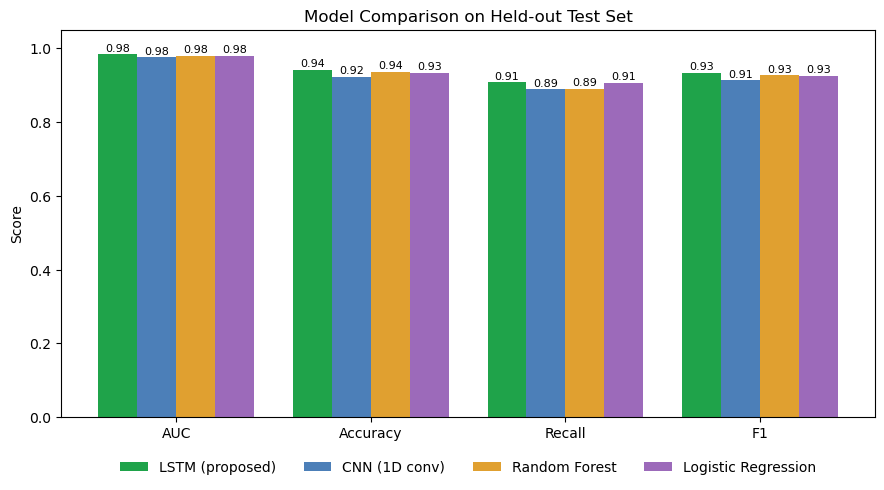

In [38]:
import matplotlib.pyplot as plt
import numpy as np

mets = ['AUC', 'Accuracy', 'Recall', 'F1']
x = np.arange(len(mets)); w = 0.2
colors = ['#1FA34A', '#4C7FB8', '#E0A030', '#9C6ABA']

fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(comparison.index):
    vals = comparison.loc[m, mets].values
    bars = ax.bar(x + (i - 1.5) * w, vals, w, label=m, color=colors[i])
    for r, v in zip(bars, vals):
        ax.text(r.get_x() + r.get_width()/2, v + 0.008, f"{v:.2f}", ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(mets); ax.set_ylim(0, 1.05)
ax.set_ylabel('Score'); ax.set_title('Model Comparison on Held-out Test Set')
ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.18), frameon=False)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()